In [22]:
import sys
import os
sys.path.append(os.path.abspath("../../src"))


# PINN 三组残差混合对比（ReLU）

本 Notebook 对比三种残差混合方式：standard / cauchy / gaussian。
统一使用 ReLU 激活，求解 Poisson 方程：

$$-\Delta u(x,y)=2\pi^2\sin(\pi x)\sin(\pi y),\quad (x,y)\in[-1,1]^2$$

边界条件：

$$u(x,y)=0,\quad (x,y)\in\partial[-1,1]^2$$

In [23]:
from dataclasses import dataclass, asdict
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from tqdm import tqdm

from cauchy_res_mixer.model import CauchyResidualMLP

torch.cuda.is_available()

True

In [24]:
@dataclass(slots=True)
class PinnExperimentConfig:
    residual_modes: tuple[str, ...] = ("standard", "cauchy", "gaussian")
    activation_mode: str = "relu"
    num_layers: int = 4
    hidden_dim: int = 64
    epochs: int = 1
    lr: float = 1e-3
    n_interior: int = 1024
    n_boundary_each: int = 256
    bc_weight: float = 20.0
    seed: int = 42
    device: str | None = None
    grid_size: int = 81
    output_dir: str = "artifacts/pinn_residual_compare_notebook"


def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_device(device_name: str | None) -> torch.device:
    if device_name is not None:
        return torch.device(device_name)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def sample_interior_points(n_points: int, device: torch.device) -> torch.Tensor:
    return torch.rand(n_points, 2, device=device) * 2.0 - 1.0


def sample_boundary_points(n_points_per_edge: int, device: torch.device) -> torch.Tensor:
    xs = torch.rand(n_points_per_edge, 1, device=device) * 2.0 - 1.0
    ys = torch.rand(n_points_per_edge, 1, device=device) * 2.0 - 1.0

    top = torch.cat([xs, torch.ones_like(xs)], dim=1)
    bottom = torch.cat([xs, -torch.ones_like(xs)], dim=1)
    left = torch.cat([-torch.ones_like(ys), ys], dim=1)
    right = torch.cat([torch.ones_like(ys), ys], dim=1)
    return torch.cat([top, bottom, left, right], dim=0)


def exact_solution(xy: torch.Tensor) -> torch.Tensor:
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    return torch.sin(math.pi * x) * torch.sin(math.pi * y)


def forcing_term(xy: torch.Tensor) -> torch.Tensor:
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    return 2.0 * math.pi**2 * torch.sin(math.pi * x) * torch.sin(math.pi * y)


def laplacian_prediction(model: nn.Module, xy: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    xy = xy.clone().detach().requires_grad_(True)
    prediction = model(xy)
    if prediction.ndim == 1:
        prediction = prediction.unsqueeze(-1)

    gradients = torch.autograd.grad(
        prediction,
        xy,
        grad_outputs=torch.ones_like(prediction),
        create_graph=True,
        retain_graph=True,
    )[0]

    u_x = gradients[:, 0:1]
    u_y = gradients[:, 1:2]

    u_xx = torch.autograd.grad(
        u_x,
        xy,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True,
    )[0][:, 0:1]

    u_yy = torch.autograd.grad(
        u_y,
        xy,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True,
        retain_graph=True,
    )[0][:, 1:2]

    return prediction, u_xx + u_yy

In [25]:
def pinn_losses(
    model: nn.Module,
    interior_points: torch.Tensor,
    boundary_points: torch.Tensor,
    bc_weight: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    _, laplacian = laplacian_prediction(model, interior_points)
    pde_residual = -laplacian - forcing_term(interior_points)
    pde_loss = torch.mean(pde_residual.pow(2))

    boundary_prediction = model(boundary_points)
    if boundary_prediction.ndim == 1:
        boundary_prediction = boundary_prediction.unsqueeze(-1)
    bc_loss = torch.mean(boundary_prediction.pow(2))

    total_loss = pde_loss + bc_weight * bc_loss
    return total_loss, pde_loss, bc_loss


@torch.no_grad()
def evaluate_model(model: nn.Module, device: torch.device, grid_size: int) -> dict[str, float | torch.Tensor]:
    coords = torch.linspace(-1.0, 1.0, grid_size, device=device)
    xx, yy = torch.meshgrid(coords, coords, indexing="ij")
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

    prediction = model(grid)
    if prediction.ndim == 1:
        prediction = prediction.unsqueeze(-1)
    target = exact_solution(grid)

    diff = prediction - target
    mse = torch.mean(diff.pow(2)).item()
    rel_l2 = (torch.linalg.norm(diff) / torch.clamp(torch.linalg.norm(target), min=1e-12)).item()
    max_abs = torch.max(torch.abs(diff)).item()

    return {
        "mse": mse,
        "rel_l2": rel_l2,
        "max_abs_error": max_abs,
        "prediction_grid": prediction.reshape(grid_size, grid_size).cpu(),
        "target_grid": target.reshape(grid_size, grid_size).cpu(),
    }


def build_model(config: PinnExperimentConfig, residual_mode: str, device: torch.device) -> CauchyResidualMLP:
    model = CauchyResidualMLP(
        input_dim=2,
        hidden_dim=config.hidden_dim,
        num_classes=1,
        num_layers=config.num_layers,
        activation_mode=config.activation_mode,
        residual_mode=residual_mode,
    )
    return model.to(device)


def train_single_run(config: PinnExperimentConfig, residual_mode: str, device: torch.device) -> dict[str, object]:
    model = build_model(config, residual_mode, device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

    history = {"loss": [], "pde_loss": [], "bc_loss": []}
    progress = tqdm(range(1, config.epochs + 1), desc=f"{residual_mode:>8s}", leave=False)

    for epoch in progress:
        interior_points = sample_interior_points(config.n_interior, device)
        boundary_points = sample_boundary_points(config.n_boundary_each, device)

        optimizer.zero_grad(set_to_none=True)
        total_loss, pde_loss, bc_loss = pinn_losses(model, interior_points, boundary_points, config.bc_weight)
        total_loss.backward()
        optimizer.step()

        history["loss"].append(float(total_loss.item()))
        history["pde_loss"].append(float(pde_loss.item()))
        history["bc_loss"].append(float(bc_loss.item()))
        progress.set_postfix_str(
            f"loss={history['loss'][-1]:.3e}, pde={history['pde_loss'][-1]:.3e}, bc={history['bc_loss'][-1]:.3e}"
        )

    evaluation = evaluate_model(model, device, config.grid_size)
    evaluation.pop("prediction_grid")
    evaluation.pop("target_grid")

    return {
        "residual_mode": residual_mode,
        "history": history,
        "metrics": evaluation,
    }

In [26]:
def plot_results(results: list[dict[str, object]], output_dir: Path) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    figure_path = output_dir / "pinn_residual_compare.png"

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for result in results:
        residual_mode = str(result["residual_mode"])
        history = result["history"]
        axes[0].plot(history["loss"], label=f"{residual_mode} total")
        axes[0].plot(history["pde_loss"], linestyle="--", label=f"{residual_mode} pde")
    axes[0].set_title("PINN training loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_yscale("log")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    residual_modes = [str(result["residual_mode"]) for result in results]
    mse_values = [float(result["metrics"]["mse"]) for result in results]
    rel_values = [float(result["metrics"]["rel_l2"]) for result in results]

    x = np.arange(len(residual_modes))
    width = 0.35
    axes[1].bar(x - width / 2, mse_values, width=width, label="MSE")
    axes[1].bar(x + width / 2, rel_values, width=width, label="Relative L2")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(residual_modes)
    axes[1].set_title("Final evaluation")
    axes[1].set_yscale("log")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return figure_path


def save_results(
    results: list[dict[str, object]], config: PinnExperimentConfig, output_dir: Path
) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    payload = {"config": asdict(config), "results": results}
    results_path = output_dir / "pinn_residual_compare.json"
    with results_path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False)
    return results_path


def run_three_way_experiment(config: PinnExperimentConfig) -> list[dict[str, object]]:
    set_seed(config.seed)
    device = resolve_device(config.device)

    results: list[dict[str, object]] = []
    for residual_mode in config.residual_modes:
        results.append(train_single_run(config, residual_mode, device))

    output_dir = Path(config.output_dir)
    save_results(results, config, output_dir)
    plot_results(results, output_dir)
    return results


config = PinnExperimentConfig(
    residual_modes=("standard", "cauchy", "gaussian"),
    activation_mode="relu",
    num_layers=4,
    hidden_dim=64,
    epochs=300,
    lr=1e-3,
    n_interior=1024,
    n_boundary_each=256,
    bc_weight=20.0,
    seed=42,
    device=None,
    grid_size=81,
    output_dir="artifacts/pinn_residual_compare_notebook",
)

config

PinnExperimentConfig(residual_modes=('standard', 'cauchy', 'gaussian'), activation_mode='relu', num_layers=4, hidden_dim=64, epochs=300, lr=0.001, n_interior=1024, n_boundary_each=256, bc_weight=20.0, seed=42, device=None, grid_size=81, output_dir='artifacts/pinn_residual_compare_notebook')

In [27]:
results = run_three_way_experiment(config)

print("Device:", config.device if config.device is not None else ("cuda" if torch.cuda.is_available() else "cpu"))
print("Done. Output dir:", config.output_dir)

rows = []
for item in results:
    m = item["metrics"]
    rows.append(
        {
            "residual_mode": item["residual_mode"],
            "mse": m["mse"],
            "rel_l2": m["rel_l2"],
            "max_abs_error": m["max_abs_error"],
        }
    )

df = pd.DataFrame(rows).sort_values("mse", ascending=True).reset_index(drop=True)
df

Device: cuda
Done. Output dir: artifacts/pinn_residual_compare_notebook


,residual_mode,mse,rel_l2,max_abs_error
0,cauchy,0.177219,0.852472,0.996279
1,gaussian,0.245621,1.003593,1.250440
2,standard,0.360948,1.216598,1.530354


Config:
{
  "residual_modes": [
    "standard",
    "cauchy",
    "gaussian"
  ],
  "activation_mode": "relu",
  "num_layers": 4,
  "hidden_dim": 64,
  "epochs": 300,
  "lr": 0.001,
  "n_interior": 1024,
  "n_boundary_each": 256,
  "bc_weight": 20.0,
  "seed": 42,
  "device": null,
  "grid_size": 81,
  "output_dir": "artifacts/pinn_residual_compare_notebook"
}

Number of runs: 3


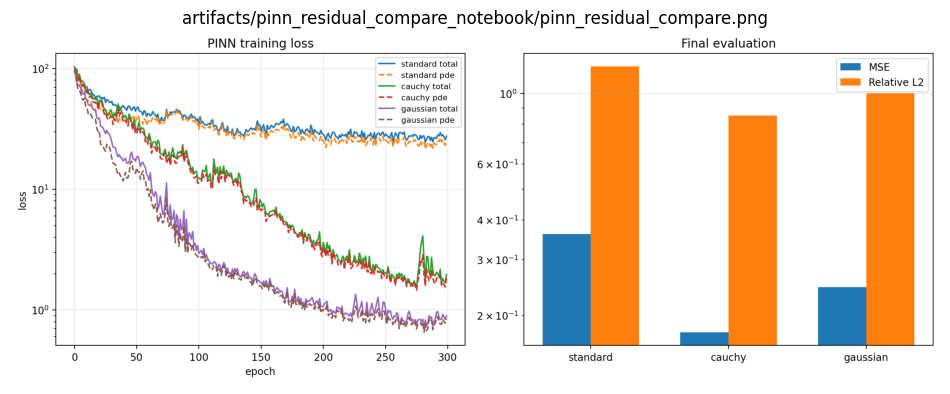

In [28]:
img_path = Path(config.output_dir) / "pinn_residual_compare.png"
if img_path.exists():
    img = plt.imread(img_path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(str(img_path))
else:
    print("Image not found:", img_path)

json_path = Path(config.output_dir) / "pinn_residual_compare.json"
if json_path.exists():
    payload = json.loads(json_path.read_text(encoding="utf-8"))
    print("Config:")
    print(json.dumps(payload["config"], indent=2, ensure_ascii=False))
    print("\nNumber of runs:", len(payload["results"]))
else:
    print("JSON not found:", json_path)